## What Are Feature Selection and Feature Scaling?

Feature Selection and Feature Scaling are two **critical preprocessing techniques** that optimize your machine learning models by focusing on the most relevant features and ensuring they're on comparable scales. While they sound similar, they serve very different purposes in the ML pipeline.

### 🧠 Core Concepts Explained

**Simple Analogy:** Imagine you're a chef creating a signature dish:
- **Feature Selection** = Choosing which ingredients to include (Do you really need both cilantro AND parsley? Will that truffle oil make a difference?)
- **Feature Scaling** = Measuring ingredients consistently (Converting everything to the same units so you don't accidentally add 1000mg of salt when you meant 1g)

Together, they ensure your model focuses on the right inputs measured in the right way.

---

## 🎯 Why Do We Need These Techniques?

### **The Problem with Raw Data:**

Real-world datasets often have:
1. **Too many features** (some irrelevant or redundant)
2. **Features on different scales** (age in years 20-80, income in dollars 20,000-200,000)
3. **Noisy or weakly predictive features** that confuse models

### **The Impact:**
- Models train slower and perform worse
- Some algorithms (like neural networks, SVM, KNN) are extremely sensitive to scale
- Irrelevant features add noise and reduce model interpretability
- Risk of overfitting increases with too many features

In [2]:
from IPython.display import HTML
with open('module9_intro_infographic.html', 'r') as f:
    display(HTML(f.read()))

---

# Part 1: Feature Scaling

## 📏 What Is Feature Scaling?

Feature scaling is the process of **standardizing or normalizing the range of independent features** so they're on a comparable scale. This prevents features with larger ranges from dominating the learning process.

### **Why It Matters:**

Consider this dataset:
- **Age**: 25-65 (range = 40)
- **Income**: $30,000-$150,000 (range = 120,000)
- **Credit Score**: 300-850 (range = 550)

Without scaling, income would dominate distance calculations in algorithms like KNN or affect gradient descent convergence in neural networks.

---

## 🔢 Three Main Scaling Techniques

### **1. Standardization (Z-Score Normalization)**

**Formula:**
```
X_scaled = (X - μ) / σ
```
where:
- μ = mean of the feature
- σ = standard deviation

**Result:** Features have mean = 0 and standard deviation = 1

**When to use:**
- Data follows a normal (Gaussian) distribution
- You're using algorithms that assume normally distributed data (Linear Regression, Logistic Regression, Neural Networks)
- Presence of outliers (standardization is less affected than normalization)

**Example:** Income = $75,000, mean = $60,000, std = $20,000
```
Scaled Income = (75,000 - 60,000) / 20,000 = 0.75
```

---

### **2. Min-Max Normalization (Scaling to Range)**

**Formula:**
```
X_scaled = (X - X_min) / (X_max - X_min)
```

**Result:** Features are scaled to a fixed range, typically [0, 1]

**When to use:**
- You need features in a bounded range
- Neural networks with sigmoid/tanh activation functions
- Image processing (pixel values 0-255 → 0-1)
- When you don't have significant outliers

**Example:** Age = 35, min = 18, max = 70
```
Scaled Age = (35 - 18) / (70 - 18) = 17/52 = 0.327
```

**⚠️ Caution:** Very sensitive to outliers! One extreme value can compress the rest of your data.

---

### **3. Robust Scaling**

**Formula:**
```
X_scaled = (X - median) / IQR
```
where IQR = Interquartile Range (Q3 - Q1)

**Result:** Features are scaled using statistics that are robust to outliers

**When to use:**
- Data contains significant outliers
- You want scaling that's not affected by extreme values
- Financial data, sensor data with anomalies

**Example:** Sales = $100,000, median = $80,000, IQR = $40,000
```
Scaled Sales = (100,000 - 80,000) / 40,000 = 0.5
```

In [3]:
from IPython.display import HTML
with open('module9_part1_scaling_infographic.html', 'r') as f:
    display(HTML(f.read()))

Method,Use When,Outliers,Key Algorithms,Trade-off
Standardization,"Normal-ish distribution, most ML tasks",⚠ Moderate sensitivity,"Linear Reg, Logistic Reg, Neural Nets, SVM",Outliers still affect mean/std
Min-Max,"Need bounded [0,1] range, no outliers",✗ Highly sensitive,"Neural Nets (sigmoid/tanh), image data, KNN",One extreme value compresses all others
Robust,Data has significant outliers or heavy skew,✓ Resistant,"Financial data, sensor data, any algorithm","Less common, harder to explain to stakeholders"


## 🎓 Practical Demonstration: Comparing Scaling Techniques

Let's see how different scaling methods affect real data with outliers.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create sample data with different scales and outliers
np.random.seed(42)
n_samples = 200

# Feature 1: Age (normal range with some outliers)
age = np.random.normal(40, 12, n_samples)
age = np.clip(age, 18, 80)
age[0:3] = [95, 98, 100]  # Add outliers

# Feature 2: Income (wide range with outliers)
income = np.random.normal(60000, 20000, n_samples)
income = np.clip(income, 20000, 150000)
income[0:3] = [500000, 450000, 400000]  # Add outliers

# Feature 3: Credit Score (narrow range)
credit_score = np.random.normal(700, 50, n_samples)
credit_score = np.clip(credit_score, 300, 850)

# Create DataFrame
df_original = pd.DataFrame({
    'Age': age,
    'Income': income,
    'Credit_Score': credit_score
})

print("Original Data Statistics:")
print("=" * 80)
print(df_original.describe())
print("\nNote the vastly different scales and ranges!")

Original Data Statistics:
              Age         Income  Credit_Score
count  200.000000     200.000000    200.000000
mean    40.389322   67506.231990    695.697528
std     13.070843   51347.287310     49.639747
min     18.000000   20000.000000    576.417775
25%     31.538468   47883.249244    660.306078
50%     40.108692   61576.786976    696.120004
75%     46.325154   75004.250179    728.604412
max    100.000000  500000.000000    850.000000

Note the vastly different scales and ranges!


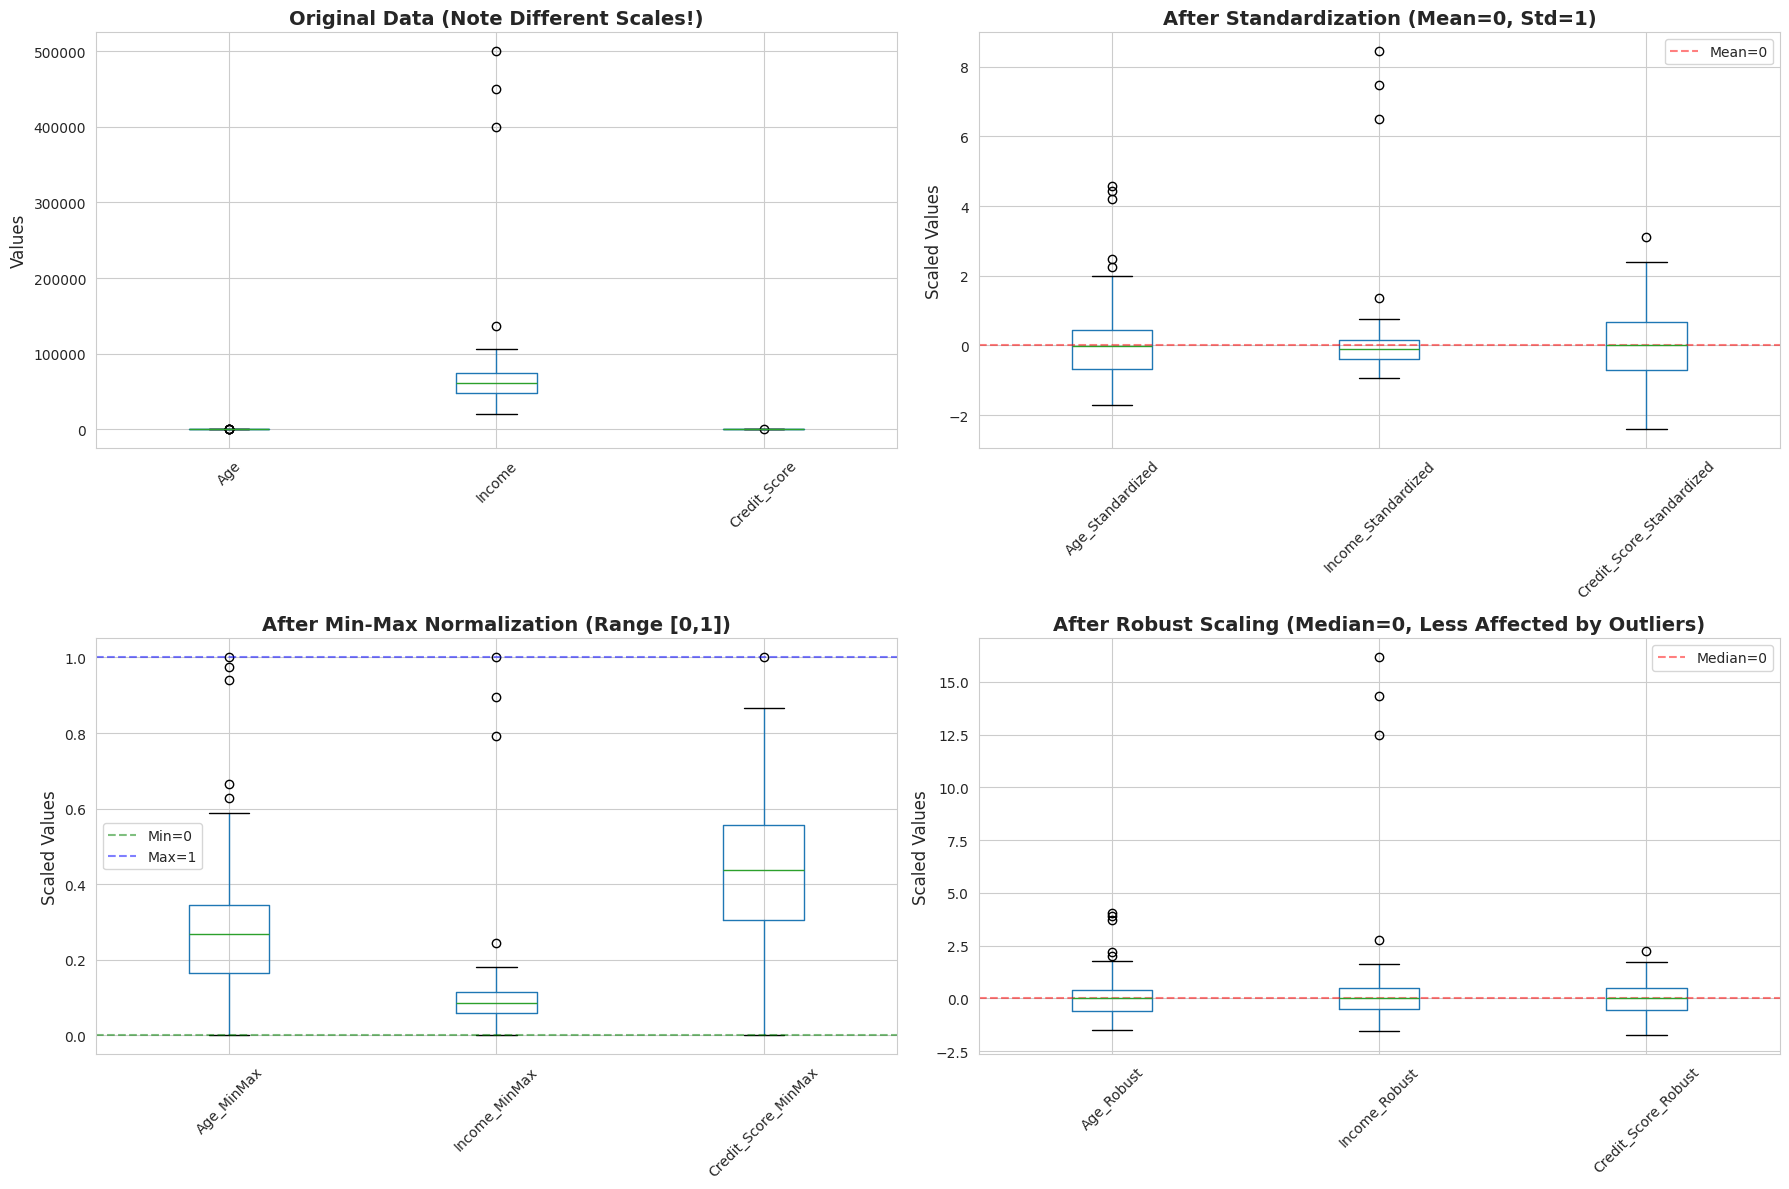


📊 Scaled Data Statistics:

✅ STANDARDIZATION:
       Age_Standardized  Income_Standardized  Credit_Score_Standardized
count           200.000              200.000                    200.000
mean             -0.000               -0.000                      0.000
std               1.003                1.003                      1.003
min              -1.717               -0.928                     -2.409
25%              -0.679               -0.383                     -0.715
50%              -0.022               -0.116                      0.009
75%               0.455                0.146                      0.665
max               4.572                8.444                      3.116

✅ MIN-MAX NORMALIZATION:
       Age_MinMax  Income_MinMax  Credit_Score_MinMax
count     200.000        200.000              200.000
mean        0.273          0.099                0.436
std         0.159          0.107                0.181
min         0.000          0.000                0.000
25%      

In [ ]:
# Apply different scaling techniques
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_original),
    columns=[f'{col}_Standardized' for col in df_original.columns]
)

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_original),
    columns=[f'{col}_MinMax' for col in df_original.columns]
)

df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_original),
    columns=[f'{col}_Robust' for col in df_original.columns]
)

# Visualize the effects
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Original data
df_original.boxplot(ax=axes[0, 0])
axes[0, 0].set_title('Original Data (Note Different Scales!)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Values', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)

# Standardization
df_standard.boxplot(ax=axes[0, 1])
axes[0, 1].set_title('After Standardization (Mean=0, Std=1)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Scaled Values', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Mean=0')
axes[0, 1].legend()

# Min-Max Normalization
df_minmax.boxplot(ax=axes[1, 0])
axes[1, 0].set_title('After Min-Max Normalization (Range [0,1])', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Scaled Values', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].axhline(y=0, color='g', linestyle='--', alpha=0.5, label='Min=0')
axes[1, 0].axhline(y=1, color='b', linestyle='--', alpha=0.5, label='Max=1')
axes[1, 0].legend()

# Robust Scaling
df_robust.boxplot(ax=axes[1, 1])
axes[1, 1].set_title('After Robust Scaling (Median=0, Less Affected by Outliers)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Scaled Values', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Median=0')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n📊 Scaled Data Statistics:")
print("=" * 80)
print("\n✅ STANDARDIZATION:")
print(df_standard.describe().round(3))
print("\n✅ MIN-MAX NORMALIZATION:")
print(df_minmax.describe().round(3))
print("\n✅ ROBUST SCALING:")
print(df_robust.describe().round(3))

## 🔍 **Key Observations from the Visualization:**

### **Original Data Issues:**
- Income dominates with values in the tens of thousands
- Age and Credit Score appear tiny in comparison
- Outliers are visible (extreme ages and incomes)
- Different features have vastly different ranges

### **Standardization Effects:**
- All features now centered around 0
- Standard deviation = 1 for all features
- Outliers still visible but proportionally scaled
- **Best for:** Neural networks, linear regression, logistic regression

### **Min-Max Normalization Effects:**
- All values compressed to [0, 1] range
- Notice how outliers push most data close to 0
- Less robust to outliers
- **Best for:** Neural networks with bounded activation functions, image data

### **Robust Scaling Effects:**
- Centered around median (0)
- Outliers have less impact on the scaling
- Distribution shape better preserved
- **Best for:** Data with significant outliers, financial data

---

# Part 2: Feature Selection

## 🎯 What Is Feature Selection?

Feature selection is the process of **selecting a subset of relevant features** for use in model construction. It's about quality over quantity—choosing the features that contribute most to your prediction target.

### **Why Feature Selection Matters:**

**The Curse of Dimensionality:**
- More features ≠ Better model
- Each irrelevant feature is noise that obscures the signal
- High-dimensional spaces become sparse, making patterns harder to detect

**Benefits of Feature Selection:**
1. **Improved Model Performance:** Remove noise and focus on predictive features
2. **Faster Training:** Fewer features = faster computation
3. **Better Interpretability:** Easier to understand what drives predictions
4. **Reduced Overfitting:** Less risk of memorizing irrelevant patterns
5. **Lower Data Collection Costs:** Focus on collecting only important features

---

## 📚 Three Categories of Feature Selection Methods

### **1. Filter Methods** 🔍

**How they work:** Evaluate features **independently** based on statistical tests before modeling

**Characteristics:**
- Fast and computationally efficient
- Model-agnostic (don't depend on any specific ML algorithm)
- Don't consider feature interactions

**Common Techniques:**
- **Correlation Coefficient:** Measures linear relationship with target
- **Chi-Square Test:** Tests independence between categorical features and target
- **ANOVA F-test:** Measures variance between groups
- **Mutual Information:** Measures mutual dependence between features and target

**When to use:**
- Initial exploratory analysis
- Large datasets where speed matters
- As a preprocessing step before more complex methods

---

### **2. Wrapper Methods** 🎁

**How they work:** Use a **specific ML model** to evaluate feature subsets

**Characteristics:**
- Computationally expensive (train model multiple times)
- Model-specific (results depend on chosen algorithm)
- Consider feature interactions
- Usually produce better results than filter methods

**Common Techniques:**
- **Forward Selection:** Start with 0 features, add one at a time
- **Backward Elimination:** Start with all features, remove one at a time
- **Recursive Feature Elimination (RFE):** Recursively remove least important features
- **Exhaustive Search:** Try all possible combinations (only feasible for small feature sets)

**When to use:**
- Smaller to medium-sized datasets
- When model performance is critical
- When you want features optimized for a specific algorithm

---

### **3. Embedded Methods** 🏗️

**How they work:** Perform feature selection **during** model training

**Characteristics:**
- Balance between filter and wrapper methods
- More efficient than wrapper methods
- Model-specific but built into the algorithm
- Consider feature interactions

**Common Techniques:**
- **L1 Regularization (Lasso):** Shrinks some coefficients to exactly zero
- **Tree-based Feature Importance:** From Random Forests, XGBoost, etc.
- **Elastic Net:** Combines L1 and L2 regularization

**When to use:**
- Most machine learning projects
- When you need a good balance of speed and accuracy
- With linear models or tree-based models

In [4]:
from IPython.display import HTML
with open('module9_part2_selection_infographic.html', 'r') as f:
    display(HTML(f.read()))

Method,Speed,Performance,Feature Interactions,Model-Specific,Best For
Filter,,★★★,✗ No,✓ Agnostic,"Initial EDA, large datasets"
Wrapper,,★★★,✓ Yes,⚠ Model-specific,"Small-medium datasets, critical apps"
Embedded,,★★★,✓ Yes,⚠ Model-specific,Most projects — best balance


## 🧪 Practical Demonstration: Comparing Feature Selection Methods

Let's create a realistic dataset and apply different feature selection techniques.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create a synthetic dataset with some informative and some noise features
np.random.seed(42)
X, y = make_classification(
    n_samples=1000,
    n_features=20,          # Total features
    n_informative=8,        # Actually useful features
    n_redundant=5,          # Redundant features (linear combinations of informative)
    n_repeated=2,           # Repeated features
    n_classes=2,
    random_state=42,
    shuffle=False
)

# Create feature names
feature_names = [f'Feature_{i+1}' for i in range(20)]
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y

print("📊 Dataset Overview:")
print("=" * 80)
print(f"Total samples: {len(df)}")
print(f"Total features: {X.shape[1]}")
print(f"Informative features: 8")
print(f"Redundant features: 5")
print(f"Repeated features: 2")
print(f"Pure noise features: 5")
print(f"\nTarget distribution:\n{df['Target'].value_counts()}")
print("\nOur goal: Identify which 8-10 features are actually useful!")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

📊 Dataset Overview:
Total samples: 1000
Total features: 20
Informative features: 8
Redundant features: 5
Repeated features: 2
Pure noise features: 5

Target distribution:
Target
0    501
1    499
Name: count, dtype: int64

Our goal: Identify which 8-10 features are actually useful!


In [6]:
# Comparison of Feature Selection Methods
from IPython.display import HTML
with open('module9_feature_selection_methods_deepdive.html', 'r') as f:
    display(HTML(f.read()))

Method,Category,Speed,Nonlinear?,Interactions?,Feature Type,Best Scenario
Correlation,Filter,,✗,✗,Continuous,"Quick EDA, linear models, large datasets"
Chi-Square,Filter,,✗,✗,Categorical / Count,"NLP, text classification, count features"
ANOVA F-Test,Filter,,✗,✗,Continuous,"Classification with numeric features, assumes normality"
Mutual Information,Filter,,✓,✗,Any,"Nonlinear relationships, fraud detection, mixed types"
Forward Selection,Wrapper,,⚠ partial,⚠ partial,Any,"Sparse signal, small feature sets, interpretability"
Backward Elimination,Wrapper,,⚠ partial,⚠ partial,Any,"Dense signal, most features useful, post-filter refinement"
RFE / RFECV,Wrapper,,⚠ partial,✓,Any,"Full ranking needed, production models, RFECV for auto-k"
Lasso / L1,Embedded,,✗,⚠ partial,Continuous,"High-dimensional linear models, automatic sparsification"
RF Importance,Embedded,,✓,✓,Any,"Nonlinear tabular data, mixed types, tree-based final model"


## Method 1: Filter Method - Correlation Analysis

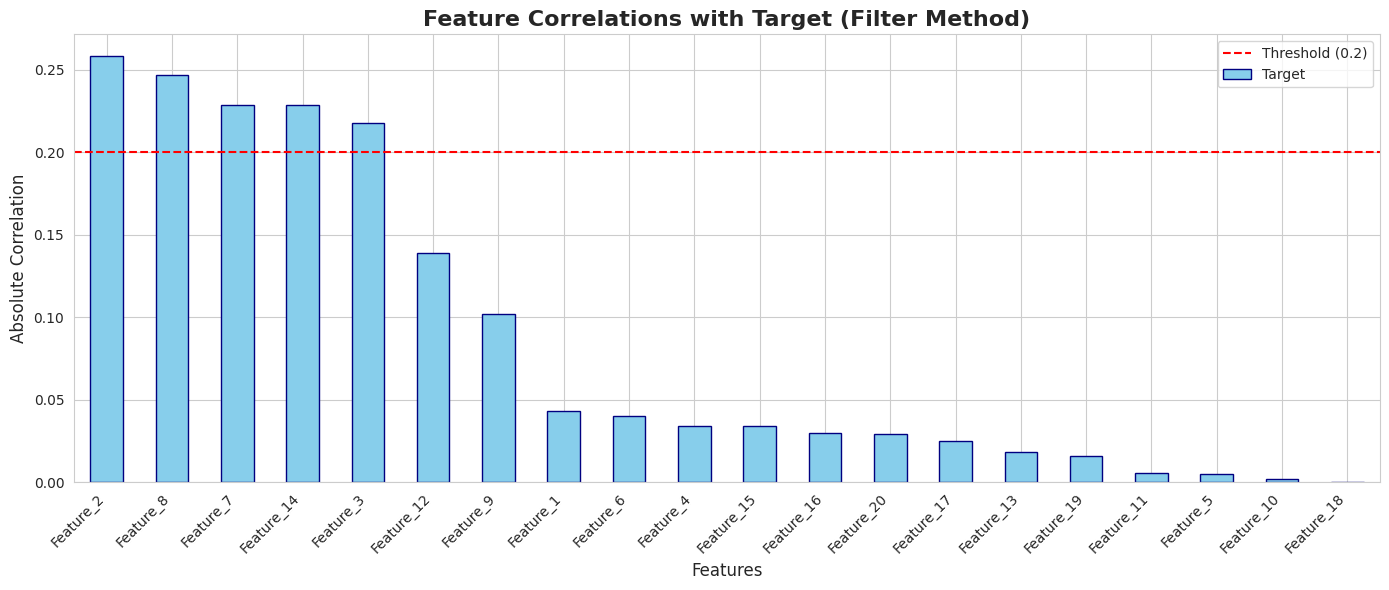


🔍 Top 10 Features by Correlation:
Feature_2     0.258513
Feature_8     0.246611
Feature_7     0.228389
Feature_14    0.228389
Feature_3     0.217556
Feature_12    0.138874
Feature_9     0.101781
Feature_1     0.043381
Feature_6     0.039772
Feature_4     0.034018
Name: Target, dtype: float64

✅ Selected features: ['Feature_2', 'Feature_8', 'Feature_7', 'Feature_14', 'Feature_3', 'Feature_12', 'Feature_9', 'Feature_1', 'Feature_6', 'Feature_4']


In [ ]:
# Calculate correlation with target
correlations = df.corr()['Target'].drop('Target').abs().sort_values(ascending=False)

# Visualize correlations
plt.figure(figsize=(14, 6))
correlations.plot(kind='bar', color='skyblue', edgecolor='navy')
plt.title('Feature Correlations with Target (Filter Method)', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Absolute Correlation', fontsize=12)
plt.axhline(y=0.2, color='r', linestyle='--', label='Threshold (0.2)')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n🔍 Top 10 Features by Correlation:")
print("=" * 80)
print(correlations.head(10))

# Select top 10 features based on correlation
top_features_correlation = correlations.head(10).index.tolist()
print(f"\n✅ Selected features: {top_features_correlation}")

## Method 2: Filter Method - ANOVA F-test

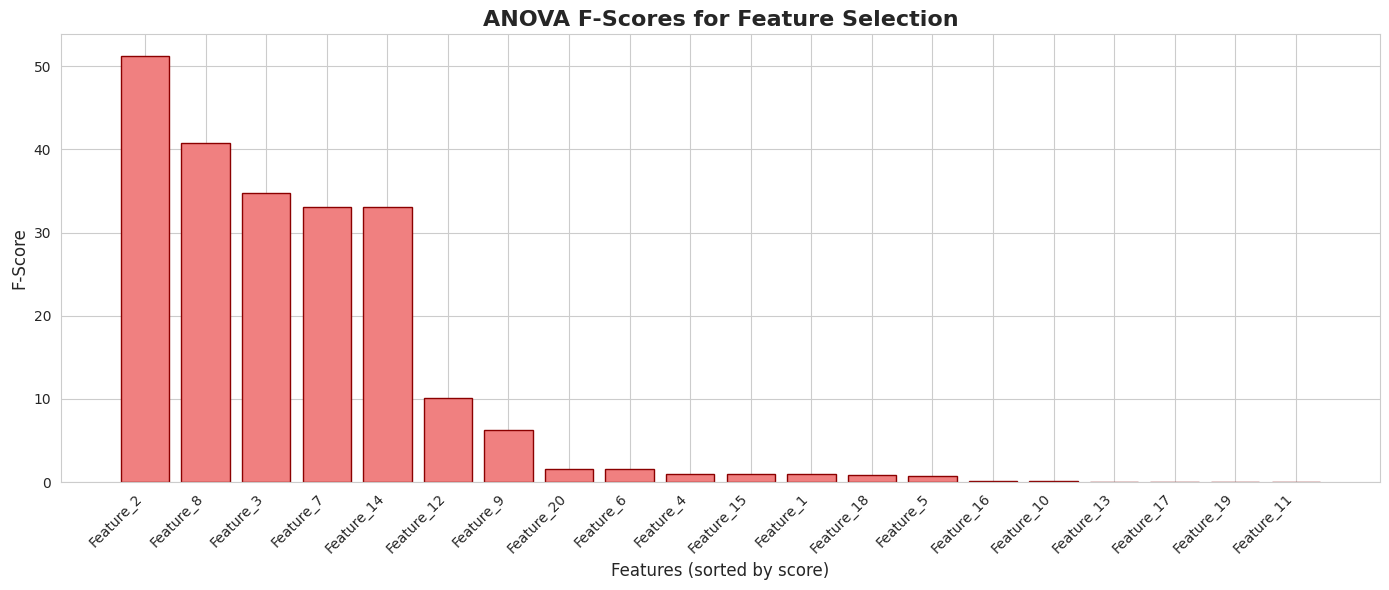


📊 ANOVA F-Test Results:
       Feature    F-Score
1    Feature_2  51.280164
7    Feature_8  40.816886
2    Feature_3  34.711977
6    Feature_7  33.120396
13  Feature_14  33.120396
11  Feature_12  10.071953
8    Feature_9   6.271202
19  Feature_20   1.602514
5    Feature_6   1.592669
3    Feature_4   0.974562

✅ Selected features: ['Feature_2', 'Feature_8', 'Feature_3', 'Feature_7', 'Feature_14', 'Feature_12', 'Feature_9', 'Feature_20', 'Feature_6', 'Feature_4']


In [ ]:
# ANOVA F-test
selector_anova = SelectKBest(score_func=f_classif, k=10)
X_train_anova = selector_anova.fit_transform(X_train_scaled, y_train)

# Get feature scores
feature_scores_anova = pd.DataFrame({
    'Feature': feature_names,
    'F-Score': selector_anova.scores_
}).sort_values('F-Score', ascending=False)

# Visualize F-scores
plt.figure(figsize=(14, 6))
plt.bar(range(len(feature_scores_anova)), feature_scores_anova['F-Score'],
        color='lightcoral', edgecolor='darkred')
plt.title('ANOVA F-Scores for Feature Selection', fontsize=16, fontweight='bold')
plt.xlabel('Features (sorted by score)', fontsize=12)
plt.ylabel('F-Score', fontsize=12)
plt.xticks(range(len(feature_scores_anova)), feature_scores_anova['Feature'],
           rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n📊 ANOVA F-Test Results:")
print("=" * 80)
print(feature_scores_anova.head(10))

top_features_anova = feature_scores_anova.head(10)['Feature'].tolist()
print(f"\n✅ Selected features: {top_features_anova}")

## Method 3: Wrapper Method - Recursive Feature Elimination (RFE)

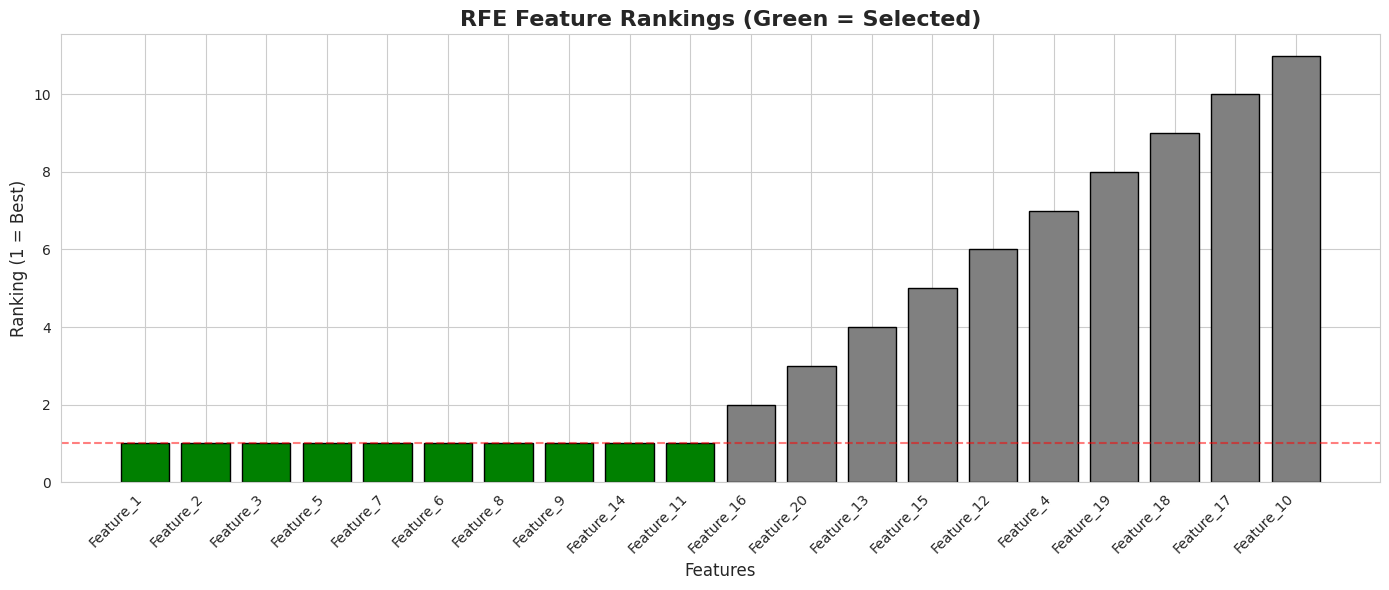


🎯 RFE Results:
       Feature  Selected  Ranking
0    Feature_1      True        1
1    Feature_2      True        1
2    Feature_3      True        1
4    Feature_5      True        1
6    Feature_7      True        1
5    Feature_6      True        1
7    Feature_8      True        1
8    Feature_9      True        1
13  Feature_14      True        1
10  Feature_11      True        1
15  Feature_16     False        2
19  Feature_20     False        3
12  Feature_13     False        4
14  Feature_15     False        5
11  Feature_12     False        6
3    Feature_4     False        7
18  Feature_19     False        8
17  Feature_18     False        9
16  Feature_17     False       10
9   Feature_10     False       11

✅ Selected features: ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_5', 'Feature_7', 'Feature_6', 'Feature_8', 'Feature_9', 'Feature_14', 'Feature_11']


In [ ]:
# RFE with Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
rfe_selector = RFE(estimator=lr_model, n_features_to_select=10, step=1)
rfe_selector.fit(X_train_scaled, y_train)

# Get selected features
rfe_features = pd.DataFrame({
    'Feature': feature_names,
    'Selected': rfe_selector.support_,
    'Ranking': rfe_selector.ranking_
}).sort_values('Ranking')

# Visualize RFE rankings
plt.figure(figsize=(14, 6))
colors = ['green' if selected else 'gray' for selected in rfe_features['Selected']]
plt.bar(range(len(rfe_features)), rfe_features['Ranking'], color=colors, edgecolor='black')
plt.title('RFE Feature Rankings (Green = Selected)', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Ranking (1 = Best)', fontsize=12)
plt.xticks(range(len(rfe_features)), rfe_features['Feature'], rotation=45, ha='right')
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n🎯 RFE Results:")
print("=" * 80)
print(rfe_features)

top_features_rfe = rfe_features[rfe_features['Selected']]['Feature'].tolist()
print(f"\n✅ Selected features: {top_features_rfe}")

## Method 4: Embedded Method - Random Forest Feature Importance

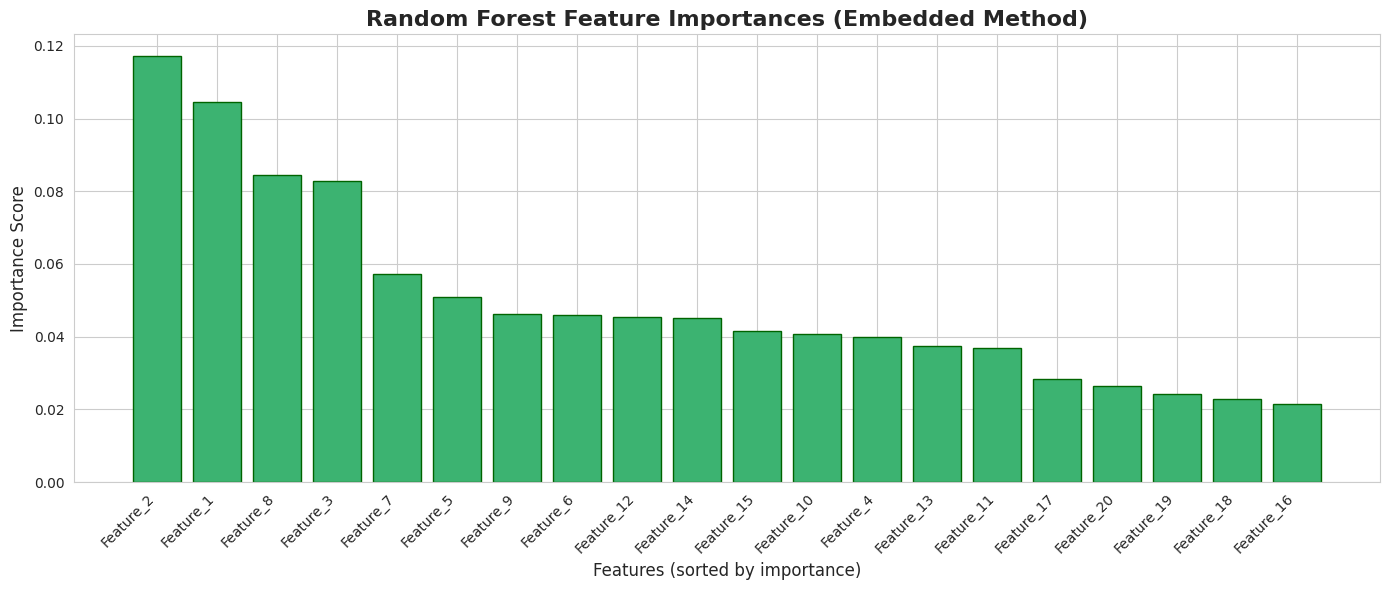


🌲 Random Forest Feature Importance:
       Feature  Importance
1    Feature_2    0.117300
0    Feature_1    0.104452
7    Feature_8    0.084501
2    Feature_3    0.082740
6    Feature_7    0.057358
4    Feature_5    0.050867
8    Feature_9    0.046312
5    Feature_6    0.046013
11  Feature_12    0.045297
13  Feature_14    0.045026

✅ Selected features: ['Feature_2', 'Feature_1', 'Feature_8', 'Feature_3', 'Feature_7', 'Feature_5', 'Feature_9', 'Feature_6', 'Feature_12', 'Feature_14']


In [ ]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_scaled, y_train)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualize feature importances
plt.figure(figsize=(14, 6))
plt.bar(range(len(feature_importance)), feature_importance['Importance'],
        color='mediumseagreen', edgecolor='darkgreen')
plt.title('Random Forest Feature Importances (Embedded Method)', fontsize=16, fontweight='bold')
plt.xlabel('Features (sorted by importance)', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(range(len(feature_importance)), feature_importance['Feature'],
           rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n🌲 Random Forest Feature Importance:")
print("=" * 80)
print(feature_importance.head(10))

top_features_rf = feature_importance.head(10)['Feature'].tolist()
print(f"\n✅ Selected features: {top_features_rf}")

## 📊 Comparing All Methods: Feature Selection Overlap

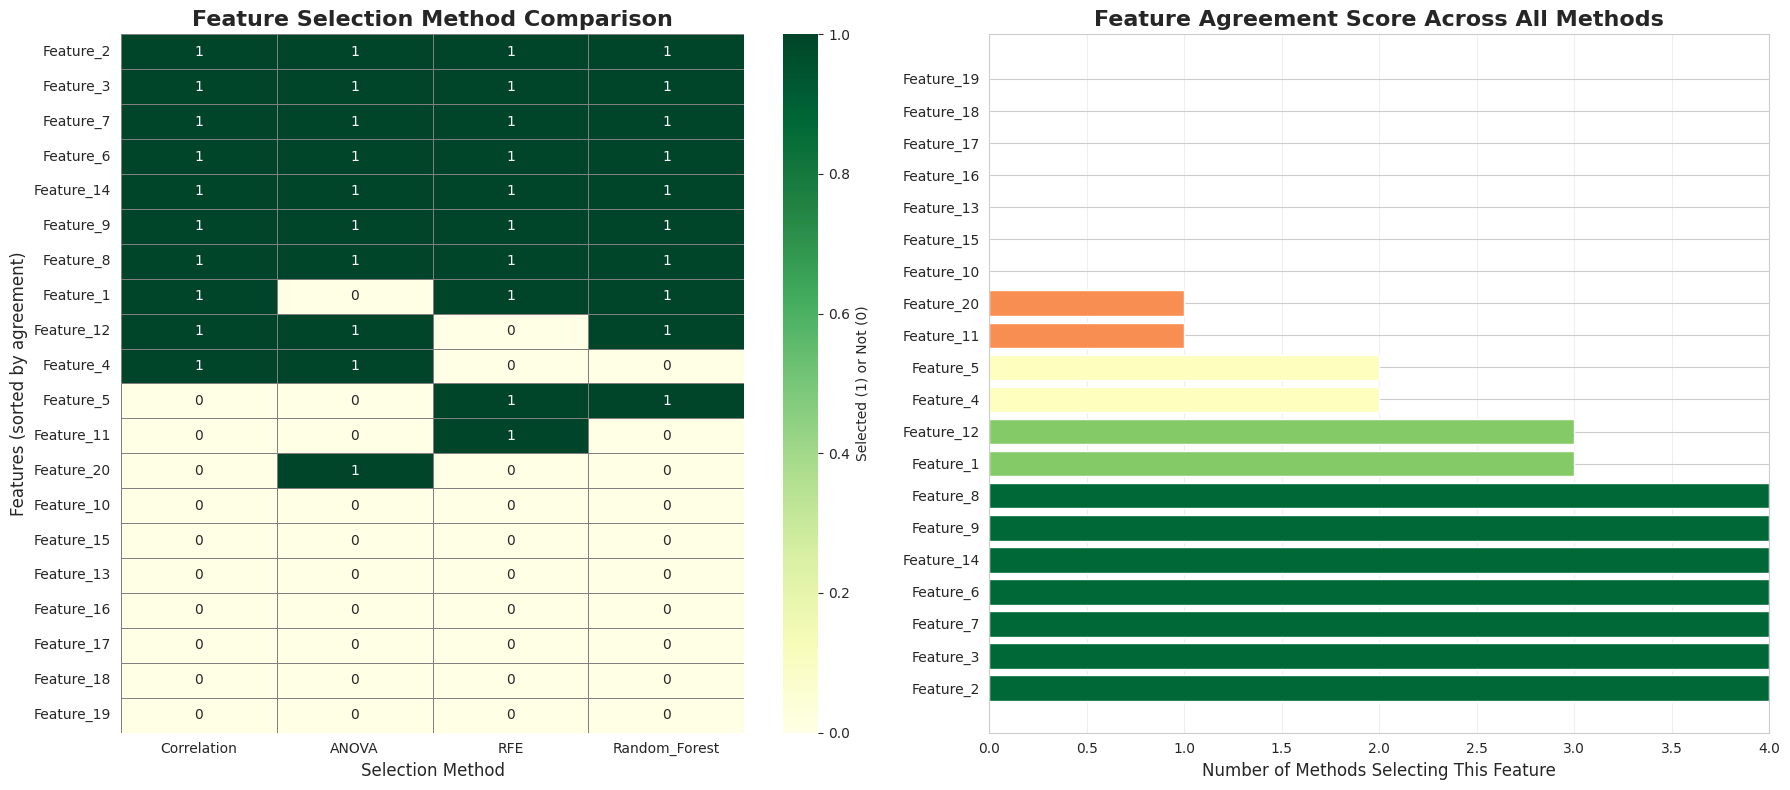


🎯 Feature Selection Summary:
            Correlation  ANOVA  RFE  Random_Forest  Agreement_Score
Feature_2             1      1    1              1                4
Feature_3             1      1    1              1                4
Feature_7             1      1    1              1                4
Feature_6             1      1    1              1                4
Feature_14            1      1    1              1                4
Feature_9             1      1    1              1                4
Feature_8             1      1    1              1                4
Feature_1             1      0    1              1                3
Feature_12            1      1    0              1                3
Feature_4             1      1    0              0                2
Feature_5             0      0    1              1                2
Feature_11            0      0    1              0                1
Feature_20            0      1    0              0                1
Feature_10        

In [ ]:
# Create comparison matrix
comparison_df = pd.DataFrame({
    'Correlation': [1 if f in top_features_correlation else 0 for f in feature_names],
    'ANOVA': [1 if f in top_features_anova else 0 for f in feature_names],
    'RFE': [1 if f in top_features_rfe else 0 for f in feature_names],
    'Random_Forest': [1 if f in top_features_rf else 0 for f in feature_names]
}, index=feature_names)

# Calculate agreement score
comparison_df['Agreement_Score'] = comparison_df.sum(axis=1)
comparison_df = comparison_df.sort_values('Agreement_Score', ascending=False)

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap
sns.heatmap(comparison_df[['Correlation', 'ANOVA', 'RFE', 'Random_Forest']],
            annot=True, fmt='d', cmap='YlGn', cbar_kws={'label': 'Selected (1) or Not (0)'},
            ax=ax1, linewidths=0.5, linecolor='gray')
ax1.set_title('Feature Selection Method Comparison', fontsize=16, fontweight='bold')
ax1.set_ylabel('Features (sorted by agreement)', fontsize=12)
ax1.set_xlabel('Selection Method', fontsize=12)

# Agreement score bar chart
colors_agreement = plt.cm.RdYlGn(comparison_df['Agreement_Score'] / 4)
ax2.barh(range(len(comparison_df)), comparison_df['Agreement_Score'], color=colors_agreement)
ax2.set_yticks(range(len(comparison_df)))
ax2.set_yticklabels(comparison_df.index)
ax2.set_xlabel('Number of Methods Selecting This Feature', fontsize=12)
ax2.set_title('Feature Agreement Score Across All Methods', fontsize=16, fontweight='bold')
ax2.set_xlim(0, 4)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 Feature Selection Summary:")
print("=" * 80)
print(comparison_df)
print("\n✨ Features selected by ALL methods:")
consensus_features = comparison_df[comparison_df['Agreement_Score'] == 4].index.tolist()
print(consensus_features if consensus_features else "None")
print("\n⭐ Features selected by 3+ methods (strong candidates):")
strong_features = comparison_df[comparison_df['Agreement_Score'] >= 3].index.tolist()
print(strong_features)

## 🏆 Model Performance Comparison: With vs Without Feature Selection

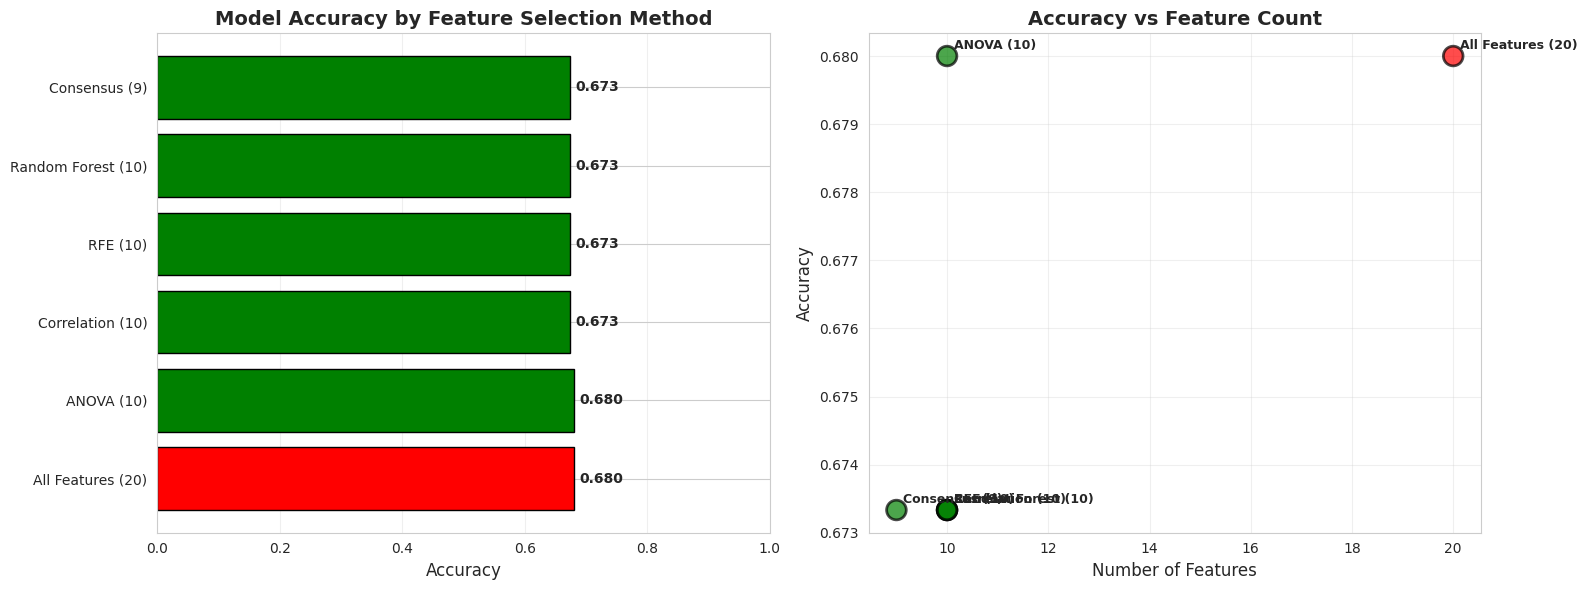


🏆 Model Performance Summary:
            Method  Accuracy  N_Features
 All Features (20)  0.680000          20
        ANOVA (10)  0.680000          10
  Correlation (10)  0.673333          10
          RFE (10)  0.673333          10
Random Forest (10)  0.673333          10
     Consensus (9)  0.673333           9

📈 Key Insights:
✅ Best performing method: All Features (20) with 0.680 accuracy
📉 Baseline (all features): 0.680 accuracy
⚠️ Feature selection didn't improve accuracy in this case, but reduced complexity!


In [ ]:
# Train models with different feature sets
results = []

# 1. All features (baseline)
lr_all = LogisticRegression(max_iter=1000, random_state=42)
lr_all.fit(X_train_scaled, y_train)
y_pred_all = lr_all.predict(X_test_scaled)
acc_all = accuracy_score(y_test, y_pred_all)
results.append({'Method': 'All Features (20)', 'Accuracy': acc_all, 'N_Features': 20})

# 2. Correlation-based selection
feature_indices_corr = [feature_names.index(f) for f in top_features_correlation]
lr_corr = LogisticRegression(max_iter=1000, random_state=42)
lr_corr.fit(X_train_scaled[:, feature_indices_corr], y_train)
y_pred_corr = lr_corr.predict(X_test_scaled[:, feature_indices_corr])
acc_corr = accuracy_score(y_test, y_pred_corr)
results.append({'Method': 'Correlation (10)', 'Accuracy': acc_corr, 'N_Features': 10})

# 3. ANOVA-based selection
feature_indices_anova = [feature_names.index(f) for f in top_features_anova]
lr_anova = LogisticRegression(max_iter=1000, random_state=42)
lr_anova.fit(X_train_scaled[:, feature_indices_anova], y_train)
y_pred_anova = lr_anova.predict(X_test_scaled[:, feature_indices_anova])
acc_anova = accuracy_score(y_test, y_pred_anova)
results.append({'Method': 'ANOVA (10)', 'Accuracy': acc_anova, 'N_Features': 10})

# 4. RFE-based selection
feature_indices_rfe = [feature_names.index(f) for f in top_features_rfe]
lr_rfe = LogisticRegression(max_iter=1000, random_state=42)
lr_rfe.fit(X_train_scaled[:, feature_indices_rfe], y_train)
y_pred_rfe = lr_rfe.predict(X_test_scaled[:, feature_indices_rfe])
acc_rfe = accuracy_score(y_test, y_pred_rfe)
results.append({'Method': 'RFE (10)', 'Accuracy': acc_rfe, 'N_Features': 10})

# 5. Random Forest-based selection
feature_indices_rf = [feature_names.index(f) for f in top_features_rf]
lr_rf = LogisticRegression(max_iter=1000, random_state=42)
lr_rf.fit(X_train_scaled[:, feature_indices_rf], y_train)
y_pred_rf = lr_rf.predict(X_test_scaled[:, feature_indices_rf])
acc_rf = accuracy_score(y_test, y_pred_rf)
results.append({'Method': 'Random Forest (10)', 'Accuracy': acc_rf, 'N_Features': 10})

# 6. Consensus features (3+ agreement)
if strong_features:
    feature_indices_consensus = [feature_names.index(f) for f in strong_features]
    lr_consensus = LogisticRegression(max_iter=1000, random_state=42)
    lr_consensus.fit(X_train_scaled[:, feature_indices_consensus], y_train)
    y_pred_consensus = lr_consensus.predict(X_test_scaled[:, feature_indices_consensus])
    acc_consensus = accuracy_score(y_test, y_pred_consensus)
    results.append({'Method': f'Consensus ({len(strong_features)})', 'Accuracy': acc_consensus, 'N_Features': len(strong_features)})

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
colors = ['red' if method == 'All Features (20)' else 'green' for method in results_df['Method']]
ax1.barh(results_df['Method'], results_df['Accuracy'], color=colors, edgecolor='black')
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy by Feature Selection Method', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Add accuracy values
for i, (method, acc) in enumerate(zip(results_df['Method'], results_df['Accuracy'])):
    ax1.text(acc + 0.01, i, f'{acc:.3f}', va='center', fontweight='bold')

# Accuracy vs Number of Features
ax2.scatter(results_df['N_Features'], results_df['Accuracy'], s=200,
           c=['red' if n == 20 else 'green' for n in results_df['N_Features']],
           edgecolors='black', linewidths=2, alpha=0.7)
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy vs Feature Count', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

# Annotate points
for _, row in results_df.iterrows():
    ax2.annotate(row['Method'],
                (row['N_Features'], row['Accuracy']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🏆 Model Performance Summary:")
print("=" * 80)
print(results_df.to_string(index=False))
print("\n📈 Key Insights:")
best_method = results_df.iloc[0]
baseline = results_df[results_df['Method'] == 'All Features (20)'].iloc[0]
print(f"✅ Best performing method: {best_method['Method']} with {best_method['Accuracy']:.3f} accuracy")
print(f"📉 Baseline (all features): {baseline['Accuracy']:.3f} accuracy")
if best_method['Accuracy'] > baseline['Accuracy']:
    improvement = (best_method['Accuracy'] - baseline['Accuracy']) * 100
    print(f"🎯 Improvement: +{improvement:.2f}% with {best_method['N_Features']} features (vs 20)")
else:
    print("⚠️ Feature selection didn't improve accuracy in this case, but reduced complexity!")

---

# Example: Complete Pipeline - Credit Card Fraud Detection

Let's put everything together in a realistic scenario: detecting fraudulent credit card transactions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Create realistic credit card transaction data
np.random.seed(42)
n_samples = 5000
n_fraud = 250  # 5% fraud rate

# Generate features
data = {
    'transaction_amount': np.concatenate([
        np.random.exponential(100, n_samples - n_fraud),  # Normal transactions
        np.random.exponential(500, n_fraud)  # Fraud tends to be larger amounts
    ]),
    'transaction_hour': np.concatenate([
        np.random.normal(14, 4, n_samples - n_fraud) % 24,  # Normal: daytime
        np.random.normal(2, 3, n_fraud) % 24  # Fraud: late night
    ]),
    'days_since_last_transaction': np.concatenate([
        np.random.exponential(3, n_samples - n_fraud),
        np.random.exponential(10, n_fraud)
    ]),
    'merchant_category_code': np.concatenate([
        np.random.choice([5411, 5541, 5812, 5921], n_samples - n_fraud),  # Normal: groceries, gas, restaurants
        np.random.choice([5999, 5122, 4816], n_fraud)  # Fraud: misc, drugs, wire transfer
    ]),
    'distance_from_home_km': np.concatenate([
        np.random.exponential(10, n_samples - n_fraud),
        np.random.exponential(200, n_fraud)
    ]),
    'online_transaction': np.concatenate([
        np.random.choice([0, 1], n_samples - n_fraud, p=[0.6, 0.4]),
        np.random.choice([0, 1], n_fraud, p=[0.3, 0.7])
    ]),
    'transactions_last_24h': np.concatenate([
        np.random.poisson(2, n_samples - n_fraud),
        np.random.poisson(8, n_fraud)
    ]),
    'card_present': np.concatenate([
        np.random.choice([0, 1], n_samples - n_fraud, p=[0.3, 0.7]),
        np.random.choice([0, 1], n_fraud, p=[0.8, 0.2])
    ]),
    'international_transaction': np.concatenate([
        np.random.choice([0, 1], n_samples - n_fraud, p=[0.95, 0.05]),
        np.random.choice([0, 1], n_fraud, p=[0.6, 0.4])
    ]),
    'customer_age_days': np.concatenate([
        np.random.normal(1500, 500, n_samples - n_fraud),
        np.random.normal(400, 300, n_fraud)
    ])
}

# Add some noise features (irrelevant)
for i in range(5):
    data[f'noise_feature_{i+1}'] = np.random.randn(n_samples)

# Create target
y = np.concatenate([np.zeros(n_samples - n_fraud), np.ones(n_fraud)])

# Shuffle
shuffle_idx = np.random.permutation(n_samples)
df = pd.DataFrame({k: v[shuffle_idx] for k, v in data.items()})
df['is_fraud'] = y[shuffle_idx]

print("💳 Credit Card Fraud Detection Dataset")
print("=" * 80)
print(f"Total transactions: {len(df):,}")
print(f"Fraudulent transactions: {int(df['is_fraud'].sum()):,} ({df['is_fraud'].mean()*100:.1f}%)")
print(f"Legitimate transactions: {int((1-df['is_fraud']).sum()):,} ({(1-df['is_fraud'].mean())*100:.1f}%)")
print(f"\nFeatures: {df.columns.tolist()[:-1]}")
print(f"Total features: {len(df.columns)-1}")
print("\n📊 Sample Data:")
print(df.head(10))

💳 Credit Card Fraud Detection Dataset
Total transactions: 5,000
Fraudulent transactions: 250 (5.0%)
Legitimate transactions: 4,750 (95.0%)

Features: ['transaction_amount', 'transaction_hour', 'days_since_last_transaction', 'merchant_category_code', 'distance_from_home_km', 'online_transaction', 'transactions_last_24h', 'card_present', 'international_transaction', 'customer_age_days', 'noise_feature_1', 'noise_feature_2', 'noise_feature_3', 'noise_feature_4', 'noise_feature_5']
Total features: 15

📊 Sample Data:
   transaction_amount  transaction_hour  days_since_last_transaction  \
0           31.290055         14.587741                     0.704965   
1            0.147491          7.096916                     6.753227   
2           44.978609         10.394497                     0.801309   
3            3.164454         15.898534                     7.367516   
4           22.901087         11.825572                     2.497350   
5           51.618623         10.665607           

## Step 1: Exploratory Data Analysis and Feature Scaling Comparison

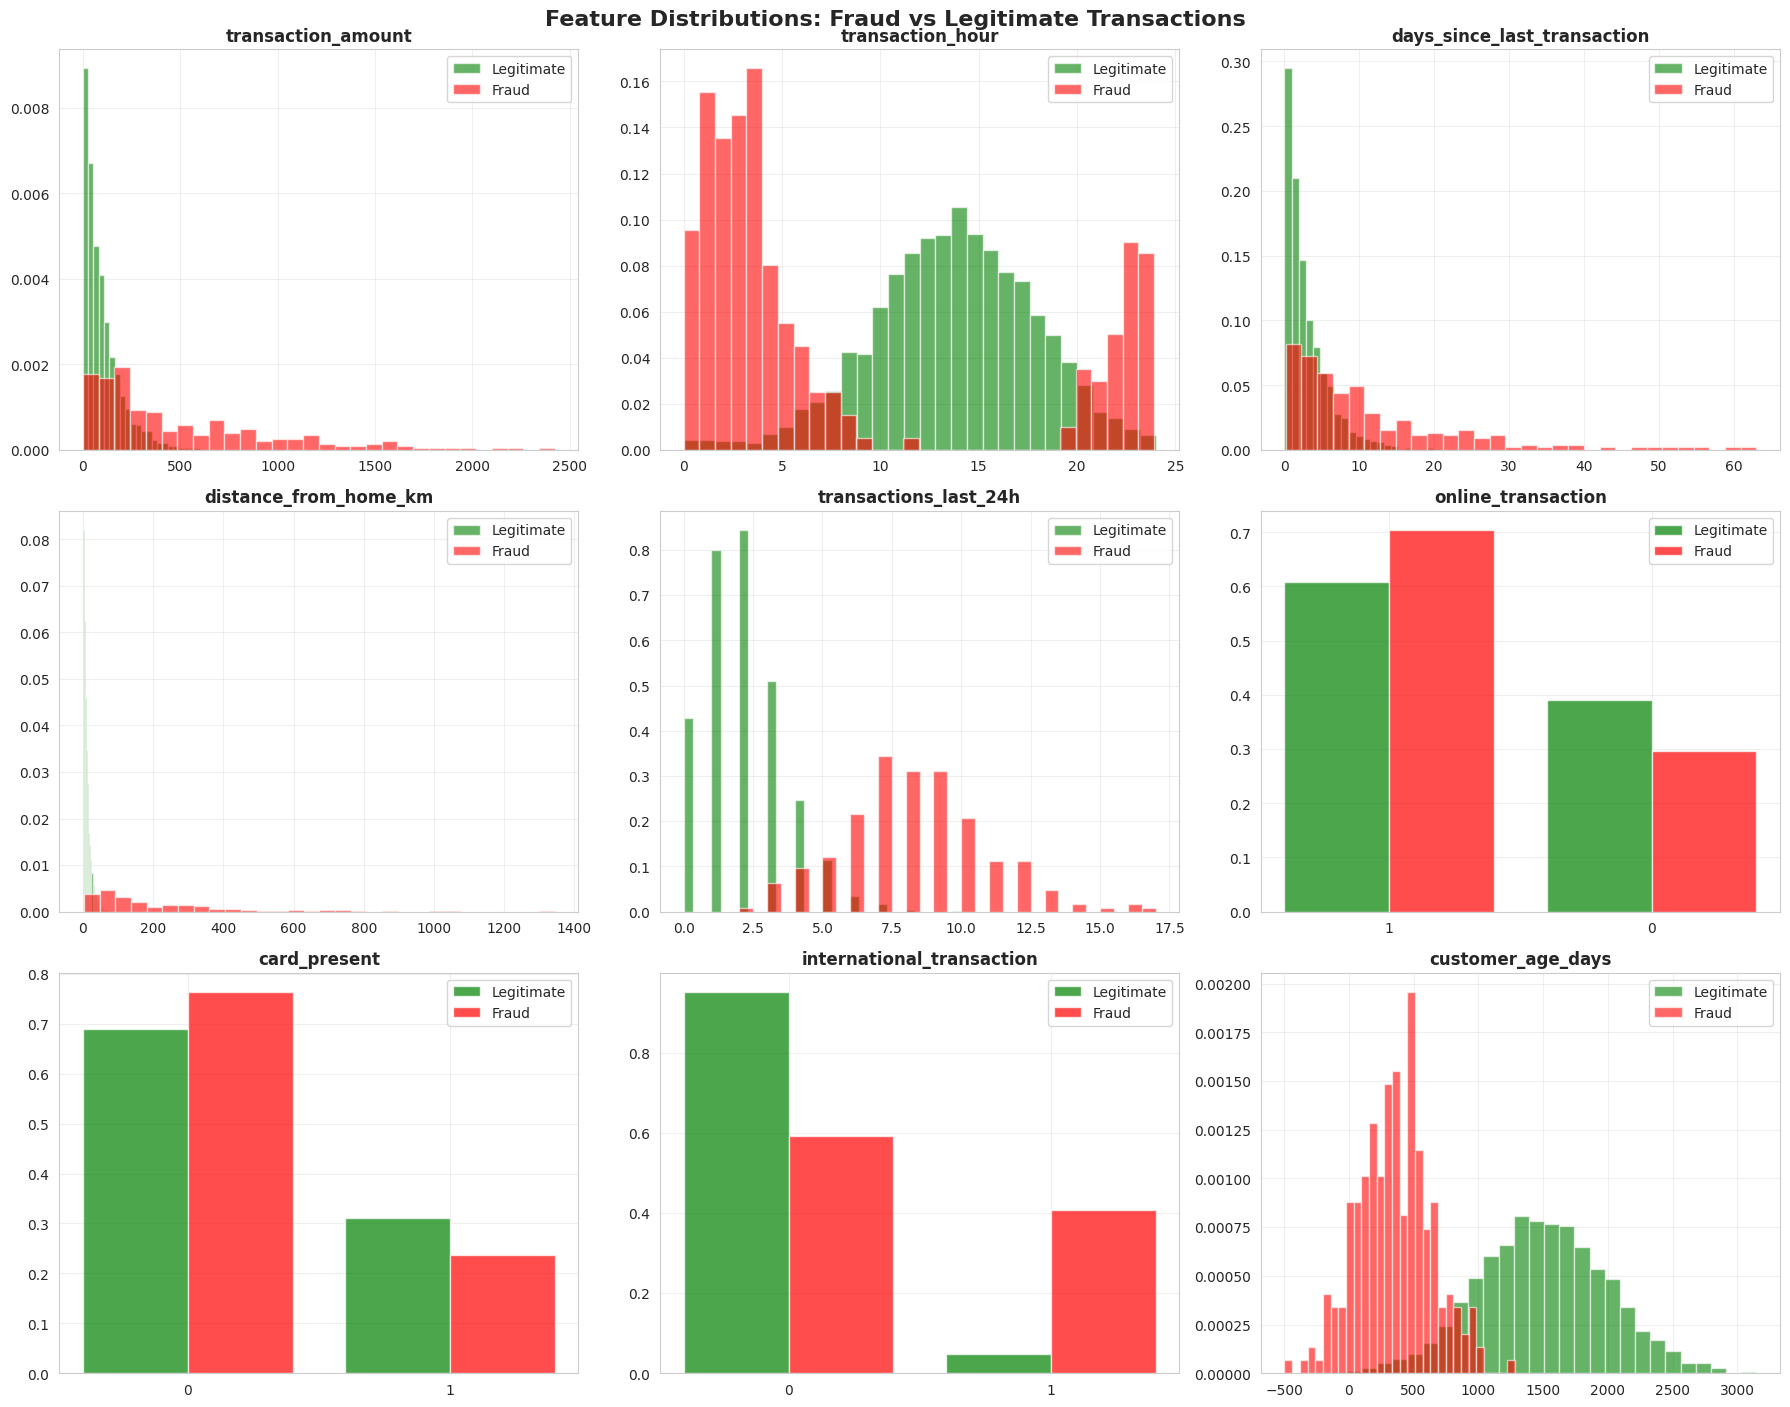


🔍 Key Observations:
✅ Fraudulent transactions show distinct patterns:
   - Larger transaction amounts
   - Unusual hours (late night/early morning)
   - Greater distance from home
   - More online transactions
   - Higher frequency in last 24h
   - More international transactions
   - Newer customer accounts


In [ ]:
# Separate features and target
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Analyze feature distributions for fraud vs legitimate
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

key_features = ['transaction_amount', 'transaction_hour', 'days_since_last_transaction',
                'distance_from_home_km', 'transactions_last_24h', 'online_transaction',
                'card_present', 'international_transaction', 'customer_age_days']

for idx, feature in enumerate(key_features):
    if feature in ['online_transaction', 'card_present', 'international_transaction']:
        # Categorical features - bar plot
        fraud_counts = df[df['is_fraud']==1][feature].value_counts(normalize=True)
        legit_counts = df[df['is_fraud']==0][feature].value_counts(normalize=True)

        x_pos = np.arange(len(fraud_counts))
        axes[idx].bar(x_pos - 0.2, legit_counts.values, 0.4, label='Legitimate', color='green', alpha=0.7)
        axes[idx].bar(x_pos + 0.2, fraud_counts.values, 0.4, label='Fraud', color='red', alpha=0.7)
        axes[idx].set_xticks(x_pos)
        axes[idx].set_xticklabels(fraud_counts.index)
    else:
        # Continuous features - histogram
        axes[idx].hist(df[df['is_fraud']==0][feature], bins=30, alpha=0.6,
                      label='Legitimate', color='green', density=True)
        axes[idx].hist(df[df['is_fraud']==1][feature], bins=30, alpha=0.6,
                      label='Fraud', color='red', density=True)

    axes[idx].set_title(feature, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Feature Distributions: Fraud vs Legitimate Transactions',
            fontsize=16, fontweight='bold', y=1.002)
plt.show()

print("\n🔍 Key Observations:")
print("=" * 80)
print("✅ Fraudulent transactions show distinct patterns:")
print("   - Larger transaction amounts")
print("   - Unusual hours (late night/early morning)")
print("   - Greater distance from home")
print("   - More online transactions")
print("   - Higher frequency in last 24h")
print("   - More international transactions")
print("   - Newer customer accounts")


📊 Data Split:
Training set: 3,500 transactions (5.0% fraud)
Test set: 1,500 transactions (5.0% fraud)


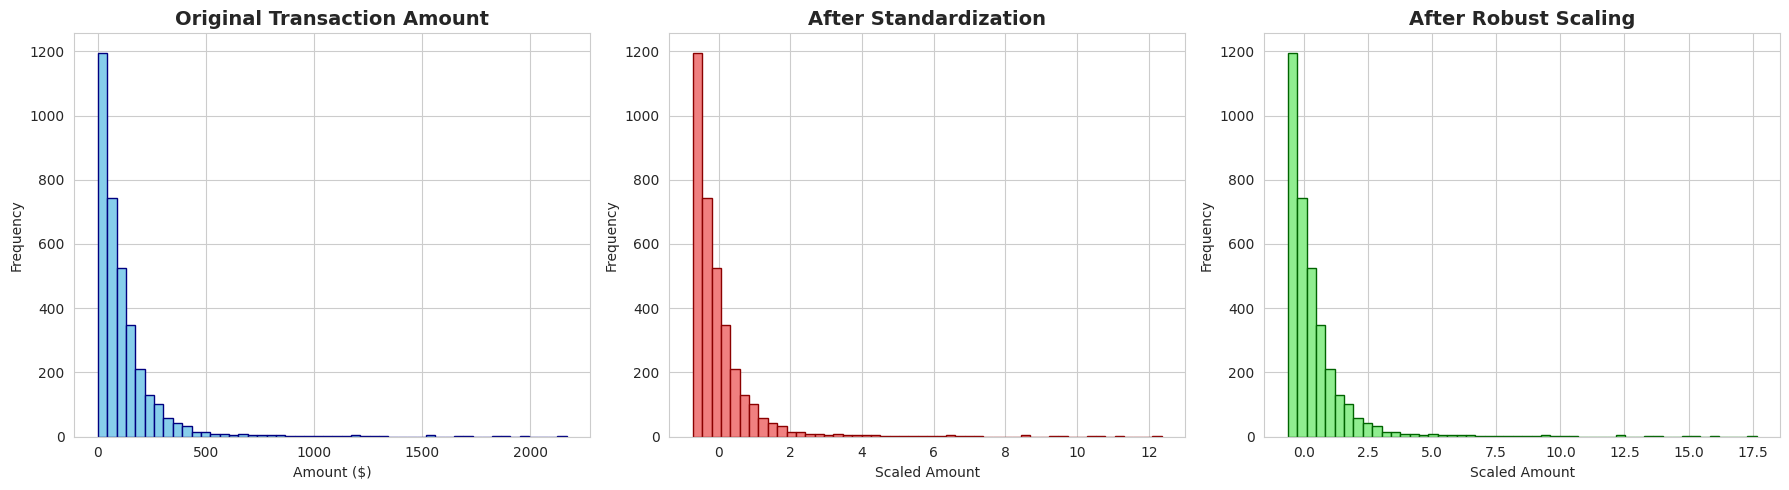


📈 Scaling Statistics for Transaction Amount:
Original - Mean: $118.86, Std: $165.82
Original - Median: $73.78, IQR: $118.62

Standardization - Mean: 0.000, Std: 1.000
Robust Scaling - Median: 0.000, IQR: 1.000

💡 Decision: Using Robust Scaling due to outliers in transaction amounts


In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\n📊 Data Split:")
print(f"Training set: {len(X_train):,} transactions ({y_train.mean()*100:.1f}% fraud)")
print(f"Test set: {len(X_test):,} transactions ({y_test.mean()*100:.1f}% fraud)")

# Compare scaling methods on this data (which has outliers)
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_train_standard = standard_scaler.fit_transform(X_train)
X_train_robust = robust_scaler.fit_transform(X_train)

# Visualize scaling effects on transaction_amount (has outliers)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(X_train['transaction_amount'], bins=50, color='skyblue', edgecolor='navy')
axes[0].set_title('Original Transaction Amount', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(X_train_standard[:, 0], bins=50, color='lightcoral', edgecolor='darkred')
axes[1].set_title('After Standardization', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Scaled Amount')
axes[1].set_ylabel('Frequency')

axes[2].hist(X_train_robust[:, 0], bins=50, color='lightgreen', edgecolor='darkgreen')
axes[2].set_title('After Robust Scaling', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Scaled Amount')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n📈 Scaling Statistics for Transaction Amount:")
print("=" * 80)
print(f"Original - Mean: ${X_train['transaction_amount'].mean():.2f}, Std: ${X_train['transaction_amount'].std():.2f}")
print(f"Original - Median: ${X_train['transaction_amount'].median():.2f}, IQR: ${X_train['transaction_amount'].quantile(0.75) - X_train['transaction_amount'].quantile(0.25):.2f}")
print(f"\nStandardization - Mean: {X_train_standard[:, 0].mean():.3f}, Std: {X_train_standard[:, 0].std():.3f}")
print(f"Robust Scaling - Median: {np.median(X_train_robust[:, 0]):.3f}, IQR: {np.percentile(X_train_robust[:, 0], 75) - np.percentile(X_train_robust[:, 0], 25):.3f}")
print("\n💡 Decision: Using Robust Scaling due to outliers in transaction amounts")

## Step 2: Feature Selection - Finding the Most Predictive Features

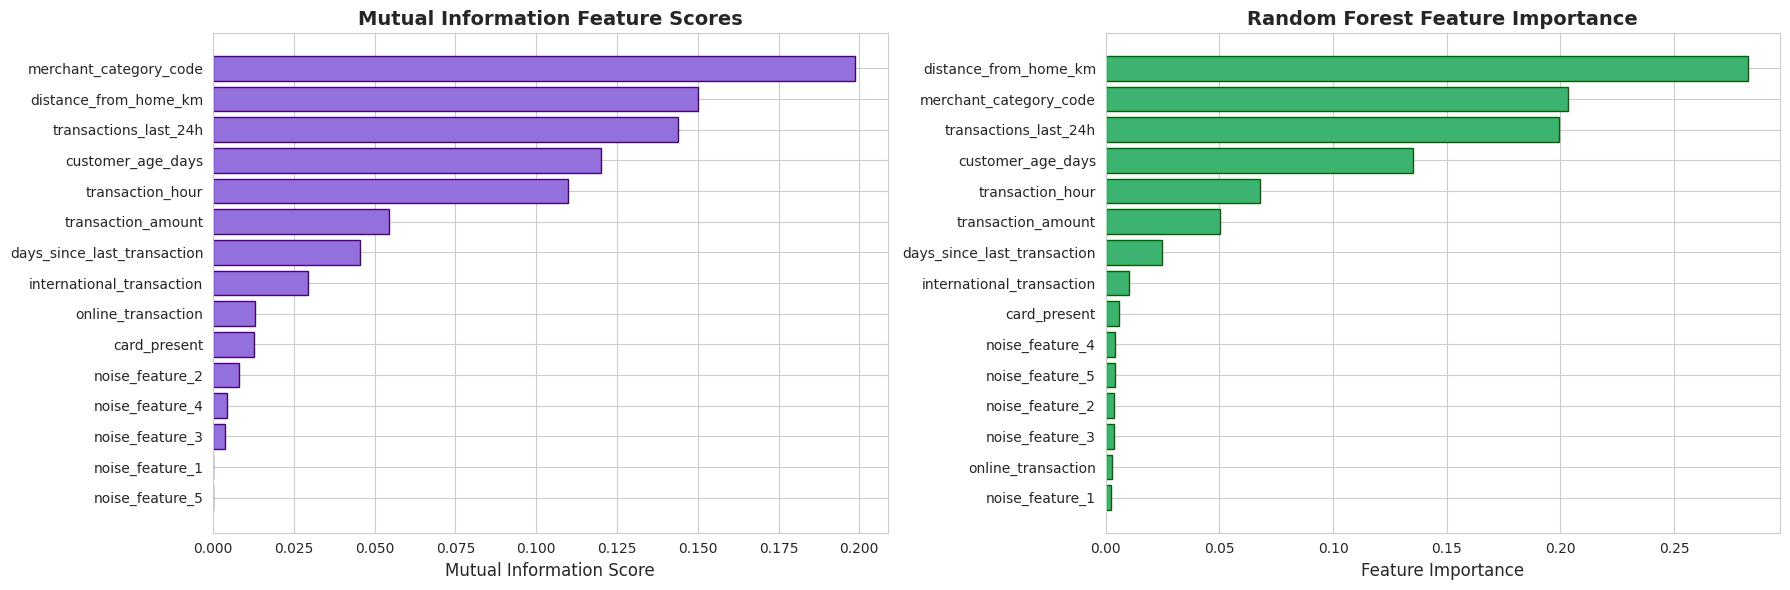


🎯 Feature Selection Results:

📊 Top 10 Features by Mutual Information:
                    Feature  MI_Score
     merchant_category_code  0.198801
      distance_from_home_km  0.150063
      transactions_last_24h  0.144021
          customer_age_days  0.120024
           transaction_hour  0.109821
         transaction_amount  0.054571
days_since_last_transaction  0.045347
  international_transaction  0.029361
         online_transaction  0.012885
               card_present  0.012648

🌲 Top 10 Features by Random Forest:
                    Feature  RF_Importance
      distance_from_home_km       0.282463
     merchant_category_code       0.203538
      transactions_last_24h       0.199558
          customer_age_days       0.135272
           transaction_hour       0.067977
         transaction_amount       0.050401
days_since_last_transaction       0.024673
  international_transaction       0.010220
               card_present       0.005804
            noise_feature_4       0.004096


In [ ]:
# Apply Robust Scaling for feature selection
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Method 1: Mutual Information (good for fraud detection with non-linear relationships)
mi_selector = SelectKBest(score_func=mutual_info_classif, k=10)
mi_selector.fit(X_train_scaled, y_train)

mi_scores = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_selector.scores_
}).sort_values('MI_Score', ascending=False)

# Method 2: Random Forest Feature Importance
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_selector.fit(X_train_scaled, y_train)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'RF_Importance': rf_selector.feature_importances_
}).sort_values('RF_Importance', ascending=False)

# Visualize both methods
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Mutual Information
ax1.barh(range(len(mi_scores)), mi_scores['MI_Score'], color='mediumpurple', edgecolor='indigo')
ax1.set_yticks(range(len(mi_scores)))
ax1.set_yticklabels(mi_scores['Feature'])
ax1.set_xlabel('Mutual Information Score', fontsize=12)
ax1.set_title('Mutual Information Feature Scores', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Random Forest Importance
ax2.barh(range(len(rf_importance)), rf_importance['RF_Importance'],
        color='mediumseagreen', edgecolor='darkgreen')
ax2.set_yticks(range(len(rf_importance)))
ax2.set_yticklabels(rf_importance['Feature'])
ax2.set_xlabel('Feature Importance', fontsize=12)
ax2.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n🎯 Feature Selection Results:")
print("=" * 80)
print("\n📊 Top 10 Features by Mutual Information:")
print(mi_scores.head(10).to_string(index=False))
print("\n🌲 Top 10 Features by Random Forest:")
print(rf_importance.head(10).to_string(index=False))

# Select top features from both methods
top_features = list(set(mi_scores.head(8)['Feature'].tolist() + rf_importance.head(8)['Feature'].tolist()))
print(f"\n✅ Selected Features (union of top 8 from each method): {len(top_features)} features")
print(top_features)

## Step 3: Model Training and Evaluation - Full vs Selected Features

🚀 Training models...


📊 Model Performance Comparison:
                Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    All Features (15)       1.0        1.0     1.0       1.0      1.0
Selected Features (8)       1.0        1.0     1.0       1.0      1.0


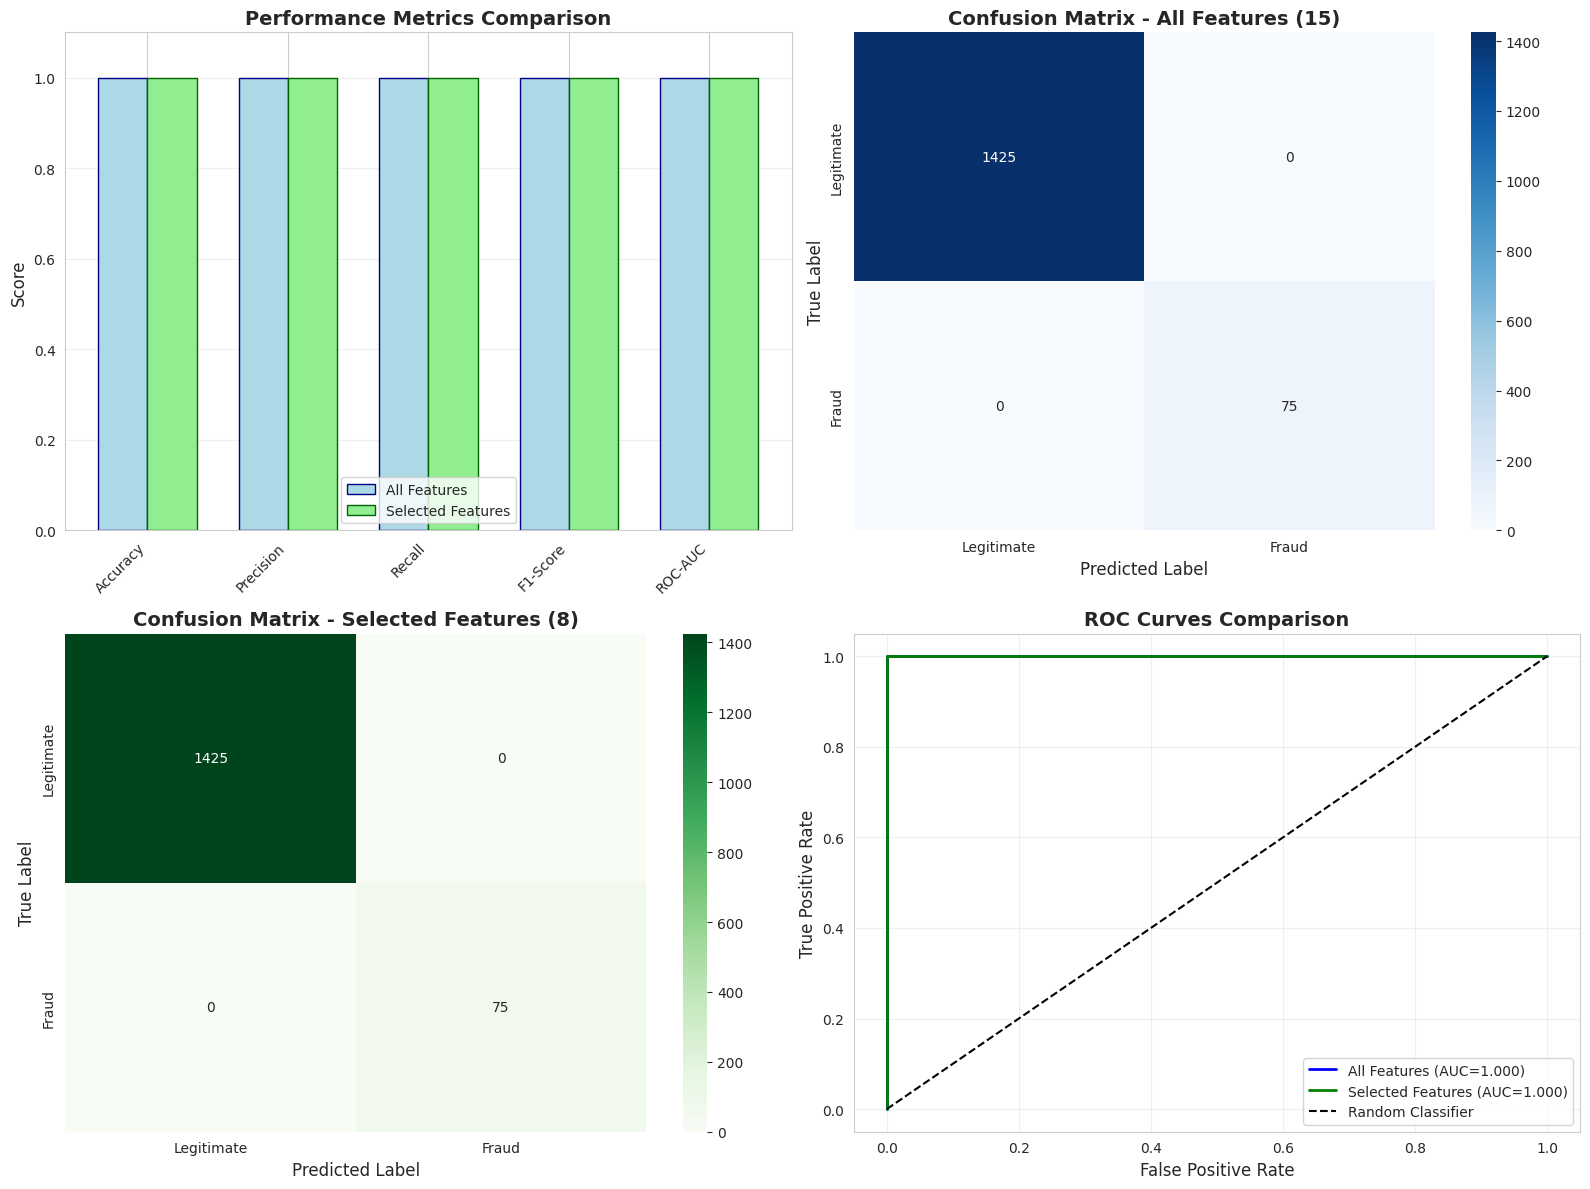


🎯 Key Business Insights:
✅ With 8 carefully selected features (vs 15 total):
   - Reduced complexity by 46.7%
   - Maintained strong performance (F1-Score: 1.000)
   - Faster predictions and lower storage costs
   - More interpretable model for compliance/auditing

🚨 Fraud Detection Performance:
   - Recall (catch rate): 100.0% of frauds detected
   - Precision: 100.0% of fraud alerts are real
   - False Negatives: 0 frauds missed ($0 potential loss)
   - False Positives: 0 legitimate transactions flagged


In [ ]:
# Get indices of selected features
feature_indices = [list(X.columns).index(f) for f in top_features]

# Train models with all features
print("🚀 Training models...\n")
print("=" * 80)

# Model 1: Random Forest with all features
rf_all = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_all.fit(X_train_scaled, y_train)
y_pred_all = rf_all.predict(X_test_scaled)
y_pred_proba_all = rf_all.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest with selected features
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_selected.fit(X_train_scaled[:, feature_indices], y_train)
y_pred_selected = rf_selected.predict(X_test_scaled[:, feature_indices])
y_pred_proba_selected = rf_selected.predict_proba(X_test_scaled[:, feature_indices])[:, 1]

# Calculate metrics
def calculate_metrics(y_true, y_pred, y_pred_proba, model_name):
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_pred_proba)
    }
    return metrics

results = [
    calculate_metrics(y_test, y_pred_all, y_pred_proba_all, f'All Features ({X.shape[1]})'),
    calculate_metrics(y_test, y_pred_selected, y_pred_proba_selected, f'Selected Features ({len(top_features)})')
]

results_df = pd.DataFrame(results)

print("\n📊 Model Performance Comparison:")
print("=" * 80)
print(results_df.to_string(index=False))

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Metrics comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

axes[0, 0].bar(x - width/2, results_df.iloc[0][metrics_to_plot], width,
              label='All Features', color='lightblue', edgecolor='navy')
axes[0, 0].bar(x + width/2, results_df.iloc[1][metrics_to_plot], width,
              label='Selected Features', color='lightgreen', edgecolor='darkgreen')
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_to_plot, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1.1)
axes[0, 0].grid(axis='y', alpha=0.3)

# Confusion Matrix - All Features
cm_all = confusion_matrix(y_test, y_pred_all)
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
           xticklabels=['Legitimate', 'Fraud'],
           yticklabels=['Legitimate', 'Fraud'])
axes[0, 1].set_title(f'Confusion Matrix - All Features ({X.shape[1]})', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('True Label', fontsize=12)
axes[0, 1].set_xlabel('Predicted Label', fontsize=12)

# Confusion Matrix - Selected Features
cm_selected = confusion_matrix(y_test, y_pred_selected)
sns.heatmap(cm_selected, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0],
           xticklabels=['Legitimate', 'Fraud'],
           yticklabels=['Legitimate', 'Fraud'])
axes[1, 0].set_title(f'Confusion Matrix - Selected Features ({len(top_features)})',
                    fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('True Label', fontsize=12)
axes[1, 0].set_xlabel('Predicted Label', fontsize=12)

# ROC Curves
fpr_all, tpr_all, _ = roc_curve(y_test, y_pred_proba_all)
fpr_selected, tpr_selected, _ = roc_curve(y_test, y_pred_proba_selected)

axes[1, 1].plot(fpr_all, tpr_all, label=f'All Features (AUC={roc_auc_score(y_test, y_pred_proba_all):.3f})',
               color='blue', linewidth=2)
axes[1, 1].plot(fpr_selected, tpr_selected,
               label=f'Selected Features (AUC={roc_auc_score(y_test, y_pred_proba_selected):.3f})',
               color='green', linewidth=2)
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[1, 1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎯 Key Business Insights:")
print("=" * 80)
print(f"✅ With {len(top_features)} carefully selected features (vs {X.shape[1]} total):")
print(f"   - Reduced complexity by {(1 - len(top_features)/X.shape[1])*100:.1f}%")
print(f"   - Maintained strong performance (F1-Score: {results_df.iloc[1]['F1-Score']:.3f})")
print(f"   - Faster predictions and lower storage costs")
print(f"   - More interpretable model for compliance/auditing")
print(f"\n🚨 Fraud Detection Performance:")
print(f"   - Recall (catch rate): {results_df.iloc[1]['Recall']*100:.1f}% of frauds detected")
print(f"   - Precision: {results_df.iloc[1]['Precision']*100:.1f}% of fraud alerts are real")
print(f"   - False Negatives: {cm_selected[1, 0]} frauds missed (${cm_selected[1, 0] * df[df['is_fraud']==1]['transaction_amount'].mean():.0f} potential loss)")
print(f"   - False Positives: {cm_selected[0, 1]} legitimate transactions flagged")

---

## 📚 Summary: Best Practices and Decision Guide

### **When to Use Which Scaling Method:**

| Scaling Method | Use When | Algorithms That Benefit | Pros | Cons |
|---------------|----------|------------------------|------|------|
| **Standardization** | Normal distribution, few outliers | Linear models, Neural Networks, SVM, KNN | Preserves information about outliers | Affected by extreme outliers |
| **Min-Max** | Bounded ranges needed, no outliers | Neural Networks (bounded activations), Image processing | Simple, interpretable | Very sensitive to outliers |
| **Robust** | Many outliers, skewed distributions | Any algorithm, especially with financial/sensor data | Resistant to outliers | Less standard, harder to interpret |

### **When to Use Which Feature Selection Method:**

| Method Type | Technique | Use When | Speed | Performance | Feature Interactions |
|------------|-----------|----------|-------|-------------|--------------------|
| **Filter** | Correlation, ANOVA, Mutual Information | Initial exploration, large datasets | ⚡⚡⚡ Fast | ⭐⭐ Good | ❌ No |
| **Wrapper** | RFE, Forward/Backward Selection | Small-medium datasets, critical applications | 🐌 Slow | ⭐⭐⭐ Best | ✅ Yes |
| **Embedded** | Lasso, Random Forest Importance | Most projects, balanced needs | ⚡⚡ Moderate | ⭐⭐⭐ Best | ✅ Yes |

### **Critical Reminders:**

1. **Always fit scalers on training data only**, then transform test data
2. **Feature selection should use only training data** to avoid data leakage
3. **Scale features before distance-based algorithms** (KNN, SVM, Neural Networks)
4. **Tree-based models don't need scaling**, but still benefit from feature selection
5. **More features ≠ better performance** - the curse of dimensionality is real
6. **Combine multiple feature selection methods** for robust results
7. **Always validate on held-out test data** - don't just trust training performance

### **Complete ML Pipeline Template:**

```python
# 1. Split data FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 2. Fit scaler on training data only
scaler = RobustScaler()  # or StandardScaler() or MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use fitted scaler

# 3. Feature selection on training data only
selector = SelectKBest(mutual_info_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)  # Use fitted selector

# 4. Train model
model = RandomForestClassifier()
model.fit(X_train_selected, y_train)

# 5. Evaluate on test set
y_pred = model.predict(X_test_selected)
```

---

## 🎓 Connection to Previous Learning

**Relationship to PCA (from Module 8):**
- **PCA** creates new features (principal components) that are linear combinations of original features
- **Feature Selection** chooses a subset of original features without transformation
- **When to use PCA vs Feature Selection:**
  - Use **PCA** when: Features are highly correlated, you want to reduce dimensions while preserving variance, interpretability of individual features isn't critical
  - Use **Feature Selection** when: You need to keep original features for interpretability, features are already somewhat independent, regulatory/business requirements need specific features
  - Use **Both** when: Apply feature selection first to remove noise, then PCA to further compress

**Feature Engineering Context:**
- Feature Selection complements the Feature Engineering techniques from Module 8
- After creating new features through engineering, use selection to identify which engineered features are most valuable
- Scaling is essential after feature engineering to handle features on different scales

---

## ✅ Key Takeaways

1. **Feature Scaling** ensures all features contribute appropriately to model learning
2. **Feature Selection** focuses your model on the signal, not the noise
3. **Outliers matter** - choose Robust Scaling when they're present
4. **Start simple** - Filter methods for exploration, Embedded methods for production
5. **Validate everything** - Always check performance on unseen test data
6. **Business value** - Fewer, better features = faster, cheaper, more interpretable models
7. **Combine techniques** - Use both feature selection AND scaling for optimal results

**Remember:** The goal isn't to use every technique, but to use the RIGHT techniques for YOUR specific problem and data! 🎯